### Import required Libraies

In [50]:
import pandas as pd 
import numpy as np 

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score

In [2]:
# load the dataset.

In [33]:
raw_data = fetch_california_housing()

In [34]:
X.shape

(20640, 8)

In [35]:
X = pd.DataFrame(raw_data.data, columns=raw_data.feature_names)

In [36]:
y = pd.DataFrame(raw_data.target, columns=raw_data.target_names)['MedHouseVal']

In [37]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [38]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [39]:
# train-test_split. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
print(X_train.shape) 
print(X_test.shape) 
print(y_train.shape) 
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [41]:
# standardization to take these values at same standard. 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
# install xgboost library first. 
pip install xgboost 

In [46]:
from xgboost import XGBRegressor

In [48]:
# create an object of xgboost.
xgb_model = XGBRegressor(n_estimoators = 100, learning_rate = 0.1, max_depth = 6, subsample = 0.8, random_state = 42)

In [51]:
# training of the model. 
xgb_model.fit(X_train_scaled, y_train)

C:\Users\Mohd Uzaif\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:57:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimoators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_estimoators=100, n_jobs=None, ...)

In [52]:
# prediction. 
y_pred = xgb_model.predict(X_test_scaled)

In [53]:
# check the r2_score 
print('R2 Score : ', r2_score(y_test, y_pred))

R2 Score :  0.8296496508304494


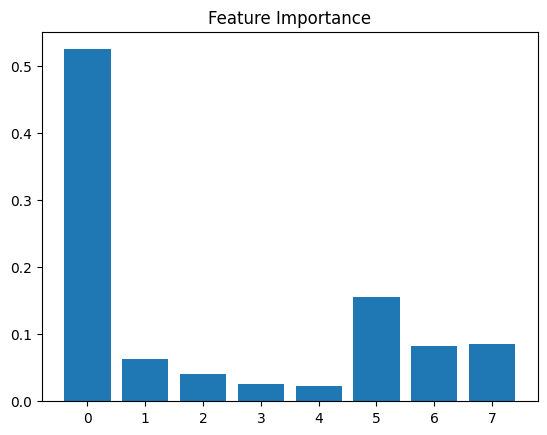

In [59]:
# feature importance. 
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()